In [ ]:
%pip install librosa pretty_midi tqdm 


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import librosa
import pretty_midi
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

run_data_processing = False

In [ ]:
FIXED_LENGTH = 128
N_BINS = 84

# Data processing functions to generate spectograms from MIDI and wav files
def midi_to_wav(midi_file, output_dir, soundfont_path):
    os.makedirs(output_dir, exist_ok=True)
    output_file = os.path.join(output_dir, os.path.basename(midi_file).replace('.mid', '.wav'))
    os.system(f'fluidsynth -ni -F "{output_file}" "{soundfont_path}" "{midi_file}"')

    if not os.path.exists(output_file):
        print(f"FAILED to create: {output_file}")\

    return output_file

def create_cqt(y, sr, hop_length=512):
    cqt = librosa.cqt(y, sr=sr, hop_length=hop_length, n_bins=N_BINS, bins_per_octave=12)
    cqt_db = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)
    return cqt_db

def pad_or_truncate(cqt, fixed_length=FIXED_LENGTH):
    if cqt.shape[1] >= fixed_length:
        return cqt[:, :fixed_length]
    pad_width = fixed_length - cqt.shape[1]
    return np.pad(cqt, ((0, 0), (0, pad_width)))

In [ ]:
midi_dir = "./test_files/Midi Files"
output_dir = "./test_files/Wav_Files"
soundfont_path = "./GeneralUser-GS/GeneralUser-GS.sf2"
save_dir = "./test_files"

all_features, all_notes, all_durations = [], [], []
failed_files = []

def process_midi_file(midi_file):
    if not midi_file.endswith('.mid'):
        return

    # print(f"Processing {midi_file}...")
    midi_path = os.path.join(midi_dir, midi_file)

    # Convert MIDI to WAV
    wav_path = midi_to_wav(midi_path, output_dir, soundfont_path)

    # Load WAV
    if not wav_path:
        return
    y, sr = librosa.load(wav_path, sr=22050)
    # Extract labels from MIDI
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    for instrument in midi_data.instruments:
        for note in instrument.notes:
            start = int(note.start * sr)
            end = int(note.end * sr)
            segment = y[start:end]

            if len(segment) == 0:
                continue

            cqt = create_cqt(segment, sr)
            cqt_fixed = pad_or_truncate(cqt)

            all_features.append(cqt_fixed)
            all_notes.append(pretty_midi.note_number_to_name(note.pitch))
            all_durations.append(round(note.end - note.start, 4))

def batch_process(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]





In [ ]:

BATCH_SIZE = 100
results, errors = [], []

if run_data_processing:
    # Process MIDI files in batches with error handling
    for batch in batch_process(os.listdir(midi_dir), BATCH_SIZE):
        for item in tqdm(batch):
            try:
                results.append(process_midi_file(item))
            except Exception as e:
                errors.append({"item": item, "error": str(e)})


  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\megan\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
c:\Users\megan\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=87
  warnings.warn(
c:\Users\megan\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=44
  warnings.warn(
 24%|██▍       | 24/100 [00:06<00:16,  4.56it/s]c:\Users\megan\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=128
  warnings.warn(
c:\Users\megan\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=6

In [26]:
print(len(all_features))

43073


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [32]:
print(results)
np.savez('all_features.npz', all_features)

[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, Non

In [ ]:
# Process all the existing wav files
# NOTE: only run it the files are created previously
midi_dir = "./test_files/Midi Files"
output_dir = "./test_files/Wav_Files"
soundfont_path = "./GeneralUser-GS/GeneralUser-GS.sf2"
save_dir = "./test_files"

if run_data_processing:
    all_features, all_notes, all_durations = [], [], []
    failed_files = []



    for wav_file in tqdm(os.listdir(output_dir)):
        if not wav_file.endswith('.wav'):
            continue

        # print(f"Processing {midi_file}...")
        wav_path = os.path.join(output_dir, wav_file)
        midi_path = os.path.join(midi_dir, wav_file.replace('.wav', '.mid'))

        # Convert MIDI to WAV
        # wav_path = midi_to_wav(midi_path, output_dir, soundfont_path)

        # Load WAV
        if not wav_path:
            continue
        y, sr = librosa.load(wav_path, sr=22050)

        # Extract labels from MIDI
        midi_data = pretty_midi.PrettyMIDI(midi_path)
        for instrument in midi_data.instruments:
            for note in instrument.notes:
                start = int(note.start * sr)
                end = int(note.end * sr)
                segment = y[start:end]

                if len(segment) == 0:
                    continue

                cqt = create_cqt(segment, sr)
                cqt_fixed = pad_or_truncate(cqt)

                all_features.append(cqt_fixed)
                all_notes.append(pretty_midi.note_number_to_name(note.pitch))
                all_durations.append(round(note.end - note.start, 4))



 43%|████▎     | 1853/4335 [07:29<10:01,  4.13it/s]


KeyboardInterrupt: 

In [33]:
# Save dataset
features = np.stack(all_features)  # shape: (num_notes, 84, 128)
df = pd.DataFrame({'note': all_notes})

np.save(os.path.join(save_dir, 'features.npy'), features)
df.to_csv(os.path.join(save_dir, 'labels.csv'), index=False)

print(f"Saved {len(df)} notes")
print(f"Features shape: {features.shape}")
print(df['note'].value_counts())

Saved 43073 notes
Features shape: (43073, 84, 128)
note
A#4    763
D#3    749
F5     743
E6     742
G5     741
      ... 
C7     672
D6     667
C2     665
B4     659
F2     652
Name: count, Length: 61, dtype: int64


In [9]:

import dataset

# get data from dataloader
train_dataset, val_dataset, test_dataset, num_classes = dataset.data_pipeline(load=False)


(43073, 84, 128)
Total notes: 43073
Unique note classes: 61
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60]


In [10]:
from model import CNN
from torch import nn
import torch.optim as optim

# Set training params
lr = 0.001
model = CNN(num_notes=61) # todo: get this number from the dataset
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
# optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # Adam optimizer performs much better

In [ ]:
import torch.nn.functional as F
import dataset
import torch
import torch.optim as optim
from tqdm import tqdm
train_losses = [] # keep train of loss


# First iteration of training using SGD optimizer
# Result: accuracy is low, around 0.018. Would require more training epochs

from basic_model import CNN

model = CNN(num_notes=61) # todo: get this number from the dataset
correct = 0
total = 0

print("Starting training loop...")

for epoch in range(2):  # loop over the dataset multiple times
    model.train()

    running_loss = 0.0
    for i, data in tqdm(enumerate(train_dataset, 0), total=len(train_dataset)):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        labels = labels.long() 

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels) # Wrong size
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

        # print statistics
        running_loss += loss.item()
        if i % 100 == 99:    # print every 2000 mini-batches
            avg_loss = running_loss / 2000
            train_losses.append(avg_loss)
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')
torch.save(model.state_dict(), "basic_model.pth")

print(f'Training accuracy: {correct / total:.4f}')


Starting training loop...


  0%|          | 0/1077 [00:00<?, ?it/s]


IndexError: Target 41 is out of bounds.

In [ ]:
import torch.nn.functional as F
import dataset
import torch
import torch.optim as optim
from tqdm import tqdm
train_losses = [] # keep train of loss


# First iteration of training using SGD optimizer
# Result: accuracy is low, around 0.018. Would require more training epochs

from model import CNN

model = CNN(num_notes=61) # todo: get this number from the dataset
correct = 0
total = 0

print("Starting training loop...")

for epoch in range(2):  # loop over the dataset multiple times
    model.train()

    running_loss = 0.0
    for i, data in tqdm(enumerate(train_dataset, 0), total=len(train_dataset)):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        labels = labels.long() 

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

        # print statistics
        running_loss += loss.item()
        if i % 100 == 99:    # print every 2000 mini-batches
            avg_loss = running_loss / 2000
            train_losses.append(avg_loss)
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

print(f'Training accuracy: {correct / total:.4f}')


Starting training loop...


100%|██████████| 1077/1077 [03:25<00:00,  5.25it/s]

Finished Training
Training accuracy: 0.0181


In [ ]:

train_losses = [] # keep train of loss

from model import CNN

model = CNN(num_notes=61) # todo: get this number from the dataset
# model.train()  # set model to training mode
correct = 0
total = 0

print("Starting training loop...")

for epoch in range(30):  # loop over the dataset multiple times
    model.train()

    running_loss = 0.0
    for i, data in tqdm(enumerate(train_dataset, 0), total=len(train_dataset)):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        labels = labels.long() 

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

        # print statistics
        running_loss += loss.item()
        if i % 100 == 99:    # print every 2000 mini-batches
            avg_loss = running_loss / 2000
            train_losses.append(avg_loss)
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

print(f'Training accuracy: {correct / total:.4f}')


Starting training loop...


  9%|▉         | 100/1077 [00:24<03:31,  4.62it/s]

[1,   100] loss: 0.214


 19%|█▊        | 200/1077 [00:46<03:04,  4.76it/s]

[1,   200] loss: 0.214


...

[3,   200] loss: 0.213


 28%|██▊       | 300/1077 [01:05<02:52,  4.51it/s]

[3,   300] loss: 0.213


 29%|██▉       | 310/1077 [01:07<02:47,  4.58it/s]


KeyboardInterrupt: 

In [ ]:
# First iteration of training using Adam optimizer
train_losses = [] # keep train of loss

from model import CNN

model = CNN(num_notes=61) # todo: get this number from the dataset
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
correct = 0
total = 0

print("Starting training loop...")

for epoch in range(2):  # loop over the dataset multiple times
    model.train()

    running_loss = 0.0
    for i, data in tqdm(enumerate(train_dataset, 0), total=len(train_dataset)):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        labels = labels.long() 

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

        # print statistics
        running_loss += loss.item()
        if i % 100 == 99:    
            avg_loss = running_loss / 100
            train_losses.append(avg_loss)
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')
torch.save(model.state_dict(), "cnn_model.pth")

print(f'Training accuracy: {correct / total:.4f}')


Starting training loop...


  9%|▉         | 100/1077 [00:22<03:56,  4.13it/s]

[1,   100] loss: 0.208


 19%|█▊        | 200/1077 [00:48<03:59,  3.66it/s]

[1,   200] loss: 0.069


...

 74%|███████▍  | 800/1077 [03:02<00:58,  4.74it/s]

[2,   800] loss: 0.000


 84%|████████▎ | 900/1077 [03:22<00:36,  4.86it/s]

[2,   900] loss: 0.001


 89%|████████▉ | 962/1077 [03:36<00:23,  4.86it/s]

In [17]:
# First iteration of training using Adam optimizer
train_losses = [] # keep train of loss

from model import CNN

model = CNN(num_notes=61) # todo: get this number from the dataset
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
correct = 0
total = 0

print("Starting training loop...")

for epoch in range(2):  # loop over the dataset multiple times
    model.train()

    running_loss = 0.0
    for i, data in tqdm(enumerate(train_dataset, 0), total=len(train_dataset)):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        labels = labels.long() 

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

        # print statistics
        running_loss += loss.item()
        if i % 100 == 99:    
            avg_loss = running_loss / 100
            train_losses.append(avg_loss)
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')
torch.save(model.state_dict(), "cnn_model.pth")

print(f'Training accuracy: {correct / total:.4f}')


Starting training loop...


  9%|▉         | 100/1077 [00:23<03:23,  4.80it/s]

[1,   100] loss: 0.194


 19%|█▊        | 200/1077 [00:45<03:09,  4.62it/s]

[1,   200] loss: 0.040


...

[2,   900] loss: 0.001


 93%|█████████▎| 1000/1077 [03:27<00:16,  4.56it/s]

[2,  1000] loss: 0.000


100%|██████████| 1077/1077 [03:44<00:00,  4.80it/s]

Finished Training
Training accuracy: 0.9342


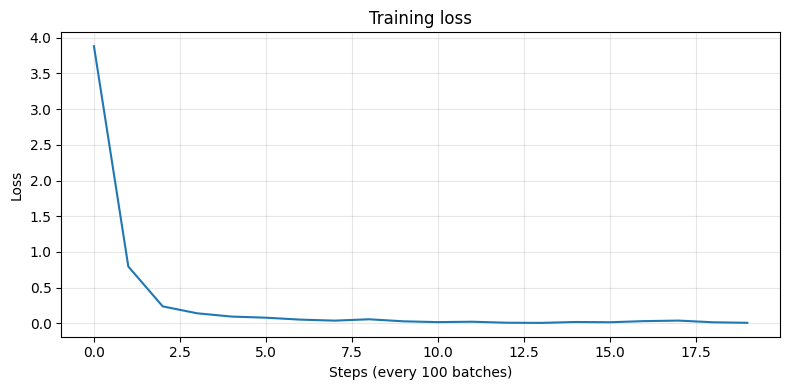

In [18]:
# Plot loss
import matplotlib.pyplot as plt
# Plot after training
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel('Steps (every 100 batches)')
plt.ylabel('Loss')
plt.title('Training loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import train
from model import CNN

import dataset

# get data from dataloader
train_dataset, val_dataset, test_dataset, num_classes = dataset.data_pipeline(load=False)

note_classifier = CNN(num_notes=num_classes)
val_losses, epoch_accuracy_scores, epoch_f1_scores = train.train(train_dataset, val_dataset, note_classifier, lr=0.001, num_classes=num_classes) # TODO: validation accuracy needs to run with more epochs




c:\Users\megan\OneDrive\Desktop\Northeastern\Spring_2026\CS4100\CS4100_Final_Project_Group20\train.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


(43073, 84, 128)
Total notes: 43073
Unique note classes: 61
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60]


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 1 / 1


  0%|          | 0/1077 [00:00<?, ?it/s]

  0%|          | 0/135 [00:00<?, ?it/s]

Epoch 1/1 - Avg Loss: 0.0042126766768470665, Validation Accuracy: 0.0, - Validation F1: 0.0


NameError: name 'torch' is not defined

In [ ]:
print (len(val_losses), len(epoch_accuracy_scores), len(epoch_f1_scores))

1 1 1


[0.0042126766768470665]


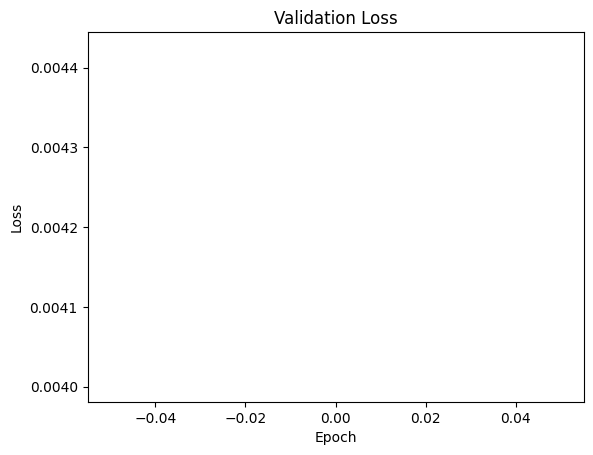

[tensor(0.)]


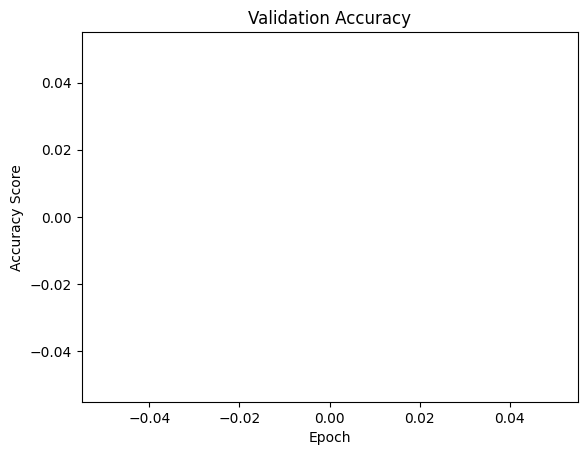

[tensor(0.)]


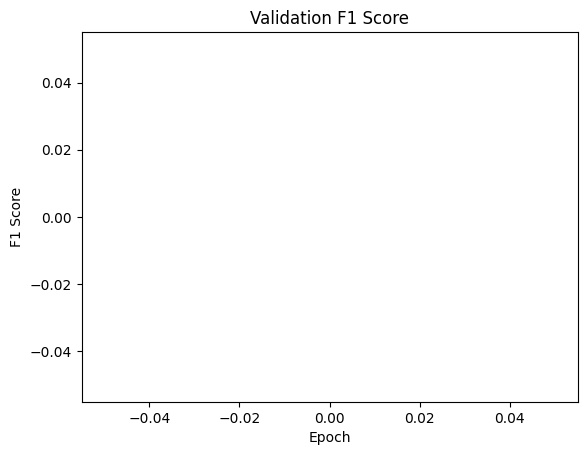

In [8]:
# torch.save(note_classifier.state_dict(), "note_classifier.pth")
import train
train.graph_losses(val_losses, title="Validation Loss")
train.graph_accuracy(epoch_accuracy_scores, title="Validation Accuracy")
train.graph_f1(epoch_f1_scores, title="Validation F1 Score")

In [ ]:
import torch
import numpy as np
from model import CNN


# Sanity check for evaluating model performance
test_model = CNN(num_notes=61)
test_model.load_state_dict(torch.load('note_classifier.pth'))  # load saved weights
test_model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():                           
    for inputs, labels in test_dataset:
        inputs, labels = inputs, labels
        labels = labels.long()

        outputs = test_model(inputs)                  
        _, predicted = outputs.max(dim=1)        # take highest scoring class

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean()
print(f"Test accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

C:\Users\megan\AppData\Local\Temp\ipykernel_26684\843380251.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_model.load_state_dict(torch.load('note_classifier.pth')

Test accuracy: 0.9991 (99.9%)


32
